In [1]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
import pandas as pd


In [2]:

iffs = fits.getdata('/raid1/mmenessini/calibration/EKARUS/data/reordered_DM468_iffs.fits').T
pupil_mask = (fits.getdata('/raid1/mmenessini/calibration/EKARUS/pupilstop/reordered_unobs_DM468_367pixels.fits')).astype(bool)
coeffs = fits.getdata('/raid1/mmenessini/results/EKARUS/atmo_phs/atmo_coeffs.fits')
phases = fits.getdata('/raid1/mmenessini/results/EKARUS/atmo_phs/ef.fits')[:,1,:,:]
print(coeffs.shape,np.max(abs(coeffs)/2e+9))


(20000, 468) 2.557052


In [3]:
ccoeffs = np.clip(coeffs*1e-9/2,-3,3).astype(np.float32)

# np.save('/raid1/mmenessini/results/EKARUS/atmo_phs/atmo_coeffs_r0_0.1m_v0_5.8mps_freq_1000Hz.npy',sscoeffs.astype(np.float32))

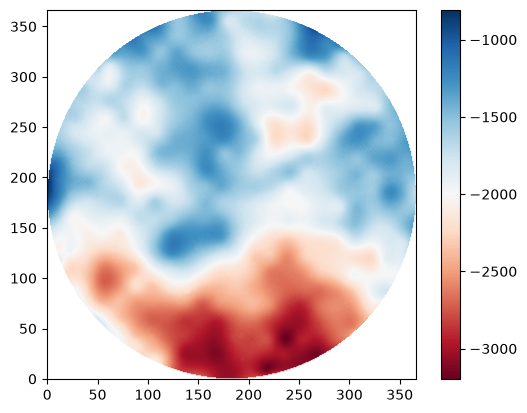

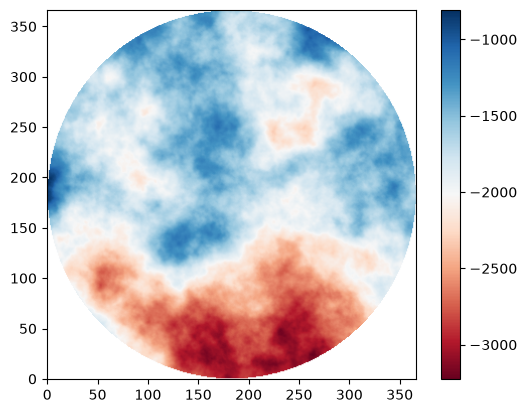

In [4]:
# recc = np.linalg.pinv(iffs) @ phases[1010][pupil_mask]

img = np.zeros(pupil_mask.shape)
img[pupil_mask] = iffs @ ccoeffs[1000]*2e+9*1.5**(5/6)

plt.figure()
plt.imshow(np.ma.masked_array(img,mask=(1-pupil_mask).astype(bool)),origin='lower',cmap='RdBu')
plt.colorbar()

plt.figure()
plt.imshow(np.ma.masked_array(phases[1000],mask=(1-pupil_mask).astype(bool)),origin='lower',cmap='RdBu')
plt.colorbar()

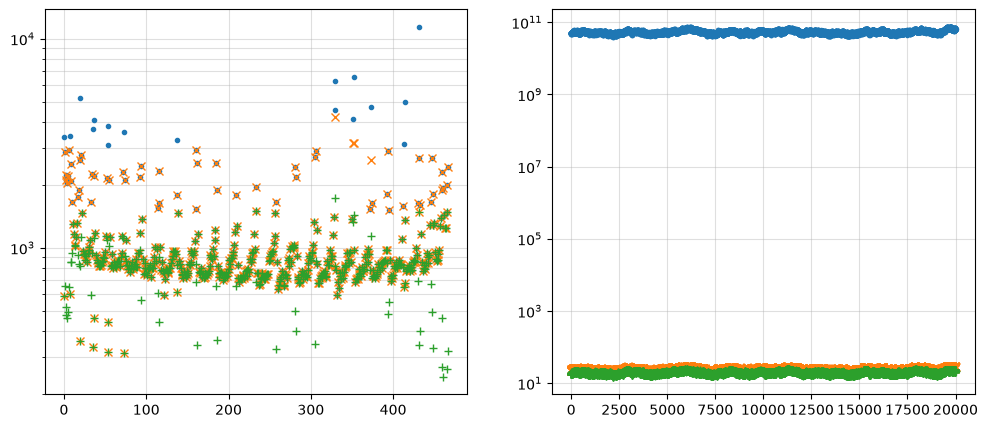

In [5]:
m2c = np.load('/raid1/mmenessini/calibration/EKARUS/m2c/M2C_KL_OOPAO_synthetic.npy')   
c2m = np.linalg.pinv(m2c)
tot = np.sum(abs(ccoeffs),axis=0)

def newslaving(coeffs,thr,Nmodes):
    tot = np.sum(abs(coeffs),axis=0)
    slave_ids = np.where(tot>thr)[0]
    slave_modes = (c2m[:,slave_ids] @ (coeffs.T)[slave_ids])
    # cmds = (m2c[slave_ids,Nmodes:] @ slave_modes[Nmodes:])
    # cmds2remove = np.zeros(coeffs.T.shape)
    # cmds2remove[slave_ids,:] = cmds
    # scoeffs = coeffs - cmds2remove.T
    cmds = (m2c[slave_ids,:Nmodes] @ slave_modes[:Nmodes])
    cmds2keep = np.zeros(coeffs.T.shape)
    cmds2keep[slave_ids,:] = cmds
    fcoeffs = coeffs.copy()
    fcoeffs[:,slave_ids] *= 0
    scoeffs = fcoeffs + cmds2keep.T
    return scoeffs

scoeffs = newslaving(ccoeffs,thr=3000,Nmodes=400)
sscoeffs = newslaving(scoeffs,thr=1500,Nmodes=200)
stot = np.sum(abs(scoeffs),axis=0)
sstot = np.sum(abs(sscoeffs),axis=0)
tot1 = np.sum(abs(coeffs),axis=1)
stot1 = np.sum(abs(scoeffs),axis=1)
sstot1 = np.sum(abs(sscoeffs),axis=1)


plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.semilogy(tot,'.')
plt.semilogy(stot,'x')
plt.semilogy(sstot,'+')
plt.grid(which='both',alpha=0.4)
plt.subplot(1,2,2)
plt.semilogy(tot1,'.')
plt.semilogy(stot1,'x')
plt.semilogy(sstot1,'+')
plt.grid(which='both',alpha=0.4)


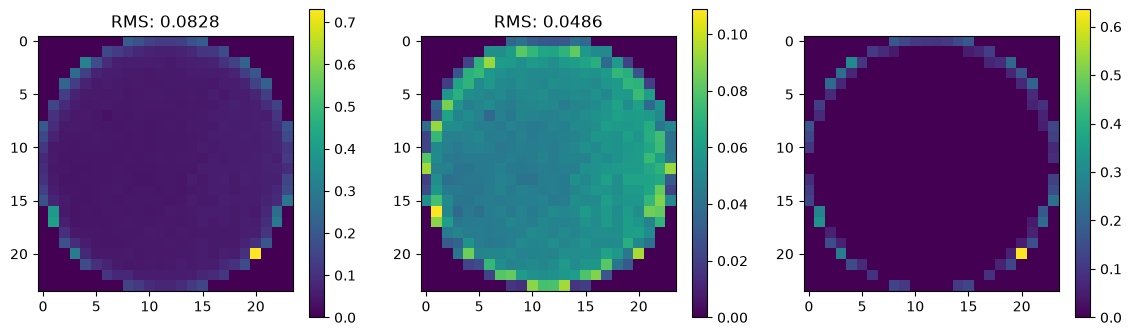

In [6]:
dm468Map = np.array([
    [0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0],
    [0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0],
    [0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0],
    [0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0],
    [0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0],
    [0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
    [0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
    [0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
    [0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0],
    [0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0],
    [0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0],
    [0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0],
    [0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0]
 ]
)

cmd = np.zeros(dm468Map.shape)
cmd[dm468Map.astype(bool)] = ccoeffs[1010]
cmd[dm468Map.astype(bool)] = np.sqrt(np.mean(ccoeffs**2,axis=0))
scmd = np.zeros(dm468Map.shape)
scmd[dm468Map.astype(bool)] = sscoeffs[1010]
scmd[dm468Map.astype(bool)] = np.sqrt(np.mean(sscoeffs**2,axis=0))

plt.figure(figsize=(14,4))
plt.subplot(1,3,1)
plt.imshow(cmd)
plt.title(f'RMS: {np.sqrt(np.mean(cmd**2)):1.4f}')
plt.colorbar()
plt.subplot(1,3,2)
plt.imshow(scmd)
plt.title(f'RMS: {np.sqrt(np.mean(scmd**2)):1.4f}')
plt.colorbar()
plt.subplot(1,3,3)
plt.imshow(cmd-scmd)
plt.colorbar()

(4736, 400) (200, 4736)


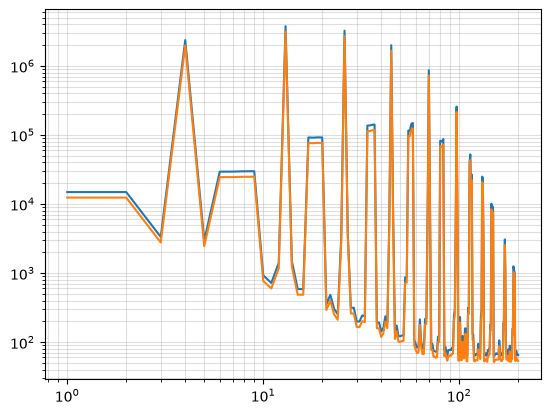

In [7]:
im = fits.getdata('/raid1/mmenessini/calibration/EKARUS/im/pyr5.0_dm468_40x40_obs_im.fits')
im_unobs = fits.getdata('/raid1/mmenessini/calibration/EKARUS/im/pyr5.0_dm468_40x40_unobs_im.fits')

Nmodes = 200

rec = np.linalg.pinv(im[:,:Nmodes])
rec_unobs = np.linalg.pinv(im_unobs[:,:Nmodes])
print(im.shape,rec.shape)

plt.figure()
plt.loglog(np.arange(Nmodes)+1,np.diag(rec @ rec.T))
plt.loglog(np.arange(Nmodes)+1,np.diag(rec_unobs @ rec_unobs.T))
plt.grid(which='both',alpha=0.4)

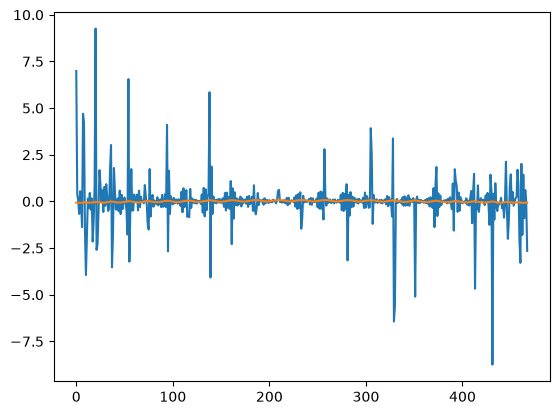

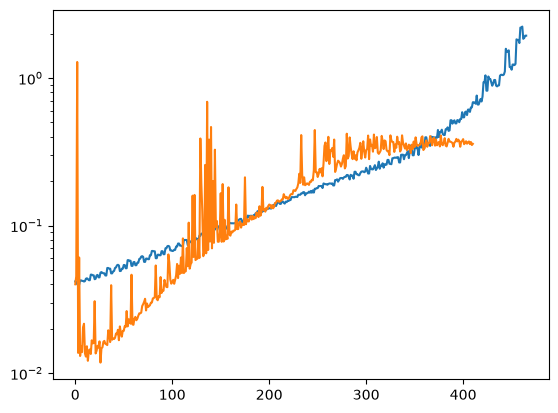

In [8]:
m2c_ref = np.load('/raid1/mmenessini/calibration/EKARUS/m2c/M2C_KL_OOPAO_synthetic.npy') 

# m2c3 = fits.getdata('/raid1/mmenessini/calibration/EKARUS/m2c/reordered_obs_DM468_m2c.fits')
# m2c0 = fits.getdata('/raid1/mmenessini/calibration/EKARUS/m2c/reordered_unobs_DM468_m2c.fits')

m2c = fits.getdata('/raid1/mmenessini/calibration/EKARUS/m2c/meas_unobs_DM468_m2c.fits')
# m2c2 = fits.getdata('/raid1/mmenessini/calibration/EKARUS/m2c/simul_unobs_DM468_m2c.fits')
# m2c2 = fits.getdata('/raid1/mmenessini/calibration/EKARUS/m2c/slaved_DM468_m2c.fits')

idx = 2
plt.figure()
# plt.plot(m2c1[:,idx]*0.04)
# plt.plot(m2c2[:,idx]*0.04)
plt.plot(m2c[:,idx]*5e-7)
# plt.ylim([-2,2])
plt.plot(m2c_ref[:,idx])
# plt.plot(m2c2[:,idx])

plt.figure()
plt.semilogy(np.std(m2c_ref,axis=0))
plt.semilogy(np.std(m2c,axis=0)*5e-7)

In [9]:
np.save('/raid1/mmenessini/calibration/EKARUS/data/M2C_KL_SPECULA_meas.npy',(m2c*5e-7).astype(np.float32))
# np.save('/raid1/mmenessini/calibration/EKARUS/data/M2C_KL_SPECULA_synthetic_central_obstruction.npy',(m2c1*0.04).astype(np.float32))

In [10]:
# m2c_loaded = np.load('/raid1/mmenessini/calibration/EKARUS/data/M2C_KL_SPECULA_synthetic_central_obstruction.npy')

# plt.figure()
# plt.plot(np.sum(m2c_loaded-m2c1*0.04,axis=1))
# plt.grid()

In [11]:
# m2c = fits.getdata('/raid1/mmenessini/calibration/SOUL/m2c/simul_s1.0_diam8.0m_m2c.fits')
# m2c_og = fits.getdata('/raid1/mmenessini/calibration/SOUL/m2c/M2C_20260908_175133.fits')
# # np.save('/raid1/mmenessini/calibration/SOUL/m2c/simul_s1.0_diam8.0m_m2c.npy',m2c.astype(np.float32))

# fits.writeto('/raid1/mmenessini/calibration/SOUL/m2c/M2C_20260909_091942.fits',m2c.astype(np.float32),overwrite=True)


In [12]:
coeffs = fits.getdata('/raid1/mmenessini/results/Cascading/atmo_phs/atmo_coeffs.fits')
print(np.max(abs(coeffs/1e+9)))

0.47695336


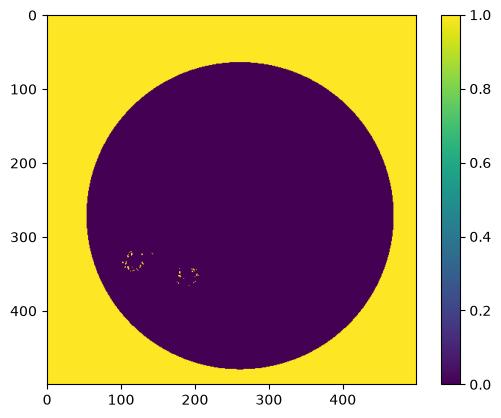

In [13]:
IF = fits.getdata('/raid1/mmenessini/calibration/Cascading/data/influence_functions.fits')

mask = np.zeros(IF.shape[1:])
for i in range(820):
    mask = np.logical_or(mask,np.isnan(IF[i]))

plt.figure()
plt.imshow(mask)
plt.colorbar()

iffs = np.zeros([np.sum(1-mask),820])
for i in range(820):
    iffs[:,i] = IF[i][~mask]


In [ ]:
# fits.writeto('/raid1/mmenessini/calibration/Cascading/data/20260831_142915_iffs.fits',iffs.astype(np.float32))
# fits.writeto('/raid1/mmenessini/calibration/Cascading/data/20260831_142915_mask.fits',mask.astype(np.uint8))
# m2c = fits.getdata('/raid1/mmenessini/calibration/SOUL/m2c/simul_s1.0_diam8.0m_m2c.fits')
# amps = np.std(iffs@m2c*2,axis=0)

# plt.figure()
# plt.plot(amps)
# plt.grid()

OSError: File /raid1/mmenessini/calibration/Cascading/data/20260831_142915_iffs.fits already exists. If you mean to replace it then use the argument "overwrite=True".

5.79924027599984e-06


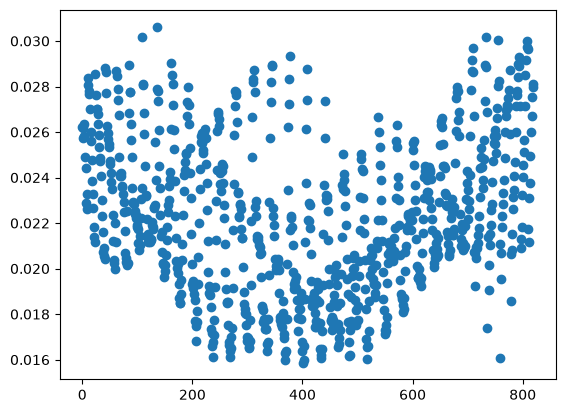

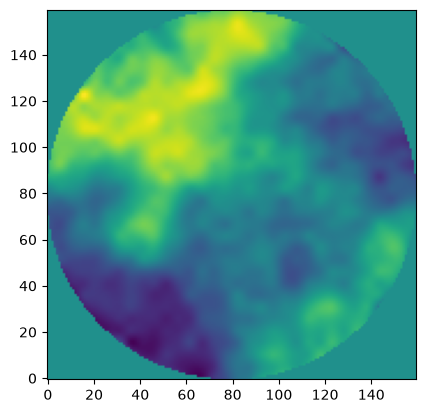

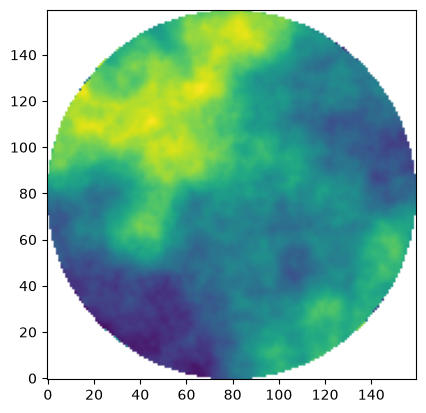

In [ ]:
mode_coeffs = fits.getdata('/raid1/mmenessini/results/Cascading/atmo_phs/atmo_coeffs.fits')
m2c = fits.getdata('/raid1/mmenessini/calibration/SOUL/m2c/simul_s1.0_diam8.0m_m2c.fits')
iffs = fits.getdata('/raid1/mmenessini/calibration/SOUL/ifunc/simul_s1.0_diam8.0m_ifunc.fits')
mask = 1-fits.getdata('/raid1/mmenessini/calibration/SOUL/pupilstop/LBT_pupil_8m_160pixels.fits')
coeffs = (m2c @ mode_coeffs.T).T
print(np.max(abs(coeffs/1e+9)))

plt.figure()
plt.plot(np.sum(abs(coeffs/1e+9),axis=0),'o')

img = np.zeros(mask.shape).flatten()
img[(1-mask).astype(bool).flatten()] = iffs @ coeffs[1000]
img = img.reshape(mask.shape)

phases = fits.getdata('/raid1/mmenessini/results/Cascading/atmo_phs/ef.fits')[:,1,:,:]
amps = fits.getdata('/raid1/mmenessini/results/Cascading/atmo_phs/ef.fits')[:,0,:,:]

plt.figure()
plt.imshow(img,origin='lower')
plt.figure()
plt.imshow(np.ma.masked_array(phases[1000],mask=np.sum(amps,axis=0)==0),origin='lower')

In [29]:
fits.writeto('/raid1/mmenessini/results/Cascading/atmo_phs/20260916_162000_atmo_coeffs.fits',(coeffs/2e+9).astype(np.float32))